# AIFS rain forecasts and electricity disruption during Indian floods
Walk-through of the pipeline (`scripts/01`–`08`). This notebook only reads saved outputs; all heavy steps ran as Slurm jobs (logs in `logs/`). The written summary is `outputs/SUMMARY.md`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown
ROOT = Path('..').resolve()
pd.set_option('display.width', 160, 'display.max_columns', 30)

## 1. Data checks
**AIFS units and timing** (`scripts/05_check_aifs_units.py`): IMD mm / raw AIFS ≈ 896 ⇒ AIFS precipitation is metres per 6 h step; `leadtime` = 6…120 h from 00 UTC.

In [2]:
print((ROOT/'logs/aifs_units_check.log').read_text()[-1500:])

251         767.81888    0.75718
2016-07-10     11.35225        0.01454         780.97601    0.60706
2016-07-11     12.51417        0.01500         834.32752    0.67206
2016-07-12     11.83436        0.01356         872.66645    0.66962
2016-07-13      9.08797        0.01007         902.65206    0.66200
2016-07-14      5.04611        0.00655         770.60663    0.49096
2016-07-15      6.72006        0.00889         755.95013    0.45397
2016-07-16     12.60817        0.01300         969.63187    0.50623
2016-07-17     13.93600        0.01452         959.68156    0.65318
2016-07-18     11.64360        0.01172         993.24018    0.58145
2016-07-19      9.57012        0.00973         983.57230    0.45877
2016-07-20      6.99147        0.00785         890.17574    0.57304
2016-07-21      7.29717        0.00779         937.16543    0.52145
2016-07-22      9.73828        0.01051         926.26801    0.56957
2016-07-23     11.75198        0.01250         940.17048    0.62917
2016-07-24     

## 2. Station coordinates

precision
locality    300
city        212
district     17
Name: count, dtype: int64


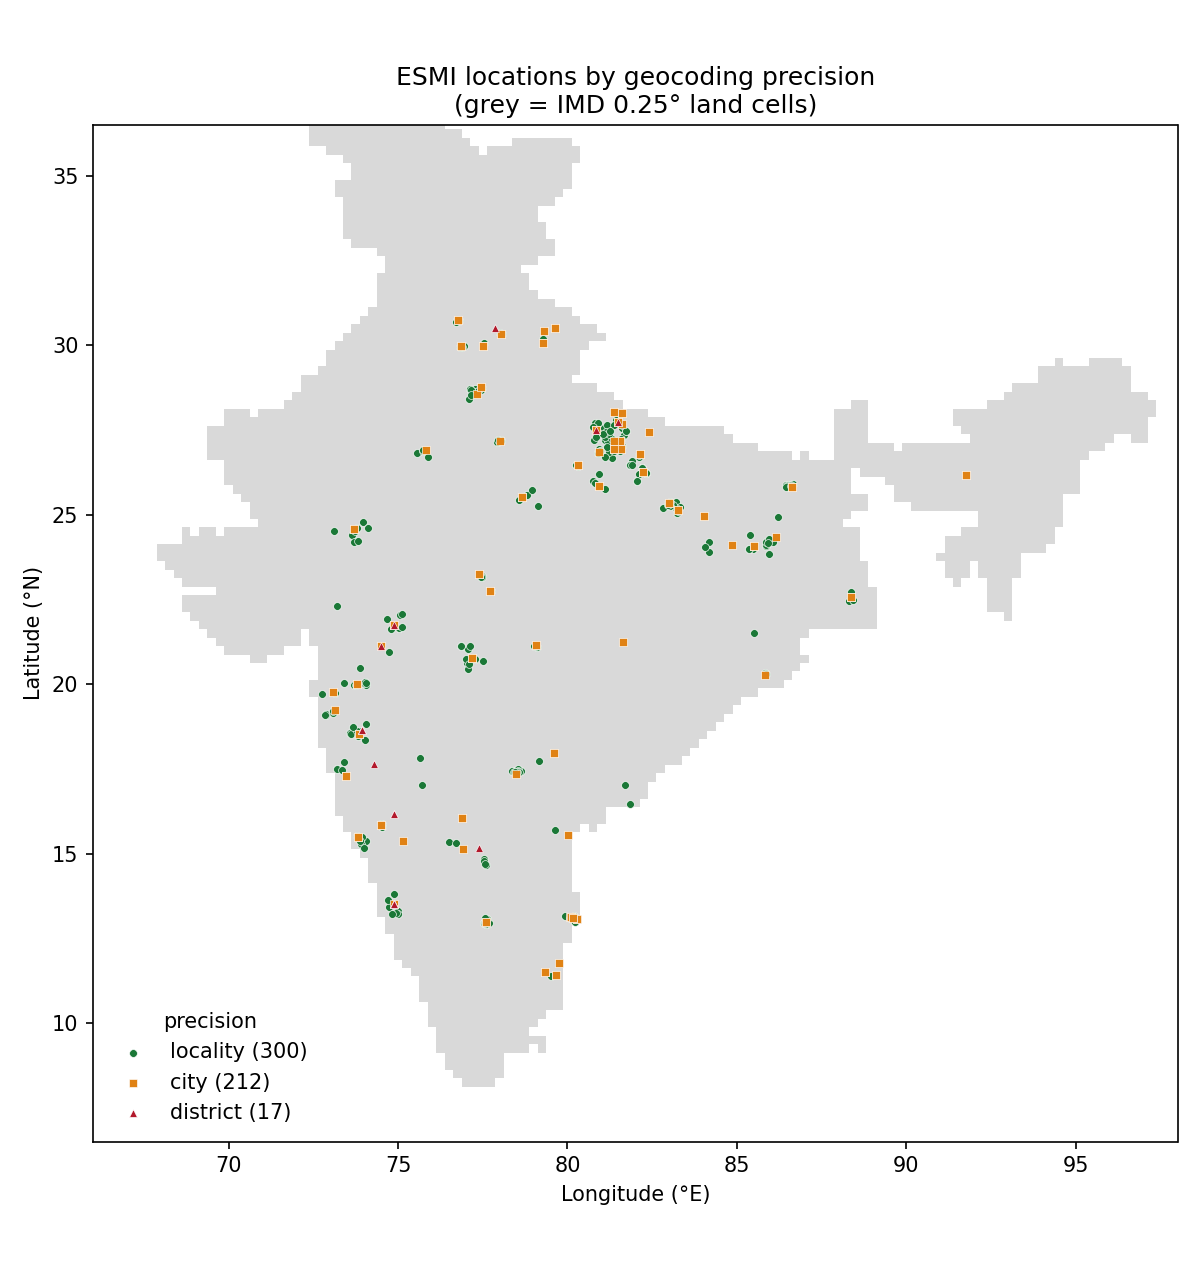

In [3]:
loc = pd.read_csv(ROOT/'data/locations.csv')
print(loc.precision.value_counts())
display(Image(str(ROOT/'outputs/figures/02_locations_map.png'), width=600))

## 3. Flood events (GFD) matched to stations
River-channel pixels (flooded in ≥ 3 of 26 events) are masked; a station is affected if ≥ 1 km² of flooding lies within 20 km, the whole event window (start − 3 d to end + 3 d) is inside its coverage, and every day is observed.

,event_id,country,began,ended,main_cause,severity,n_affected,n_affected_in_coverage,n_keep_strict,n_keep_lenient,n_keep_raw_rule,n_keep_needs_geocode_fix,used
2,4251,India,2015-05-17,2015-05-21,Torrential Rain,1.0,28,2,1,1,1,0,True
6,4282,India,2015-07-15,2015-08-19,Monsoonal Rain and Tropical Storm K,2.0,98,5,2,3,7,1,True
9,4309,India,2015-11-10,2015-12-04,Tropical Storm Rovan,2.0,44,15,5,8,8,1,True
13,4378,India,2016-07-07,2016-08-03,Monsoonal Rain,1.5,61,18,8,10,27,4,True
14,4382,Bangladesh,2016-07-25,2016-08-26,Monsoonal Rain,1.5,116,32,18,22,27,4,True
15,4459,Bangladesh,2017-03-30,2017-04-18,Heavy Rain,1.0,11,11,9,11,9,8,True
16,4483,India,2017-06-02,2017-07-03,Monsoonal Rain,1.0,11,11,10,10,10,8,True
18,4507,India,2017-08-10,2017-08-26,Monsoonal Rain,2.0,35,11,5,6,32,2,True
19,4508,Bangladesh,2017-08-10,2017-08-26,Monsoonal Rain,1.5,46,22,13,14,40,9,True
23,4665,India,2018-08-02,2018-08-10,Monsoonal Rain,1.5,11,6,5,6,5,5,True


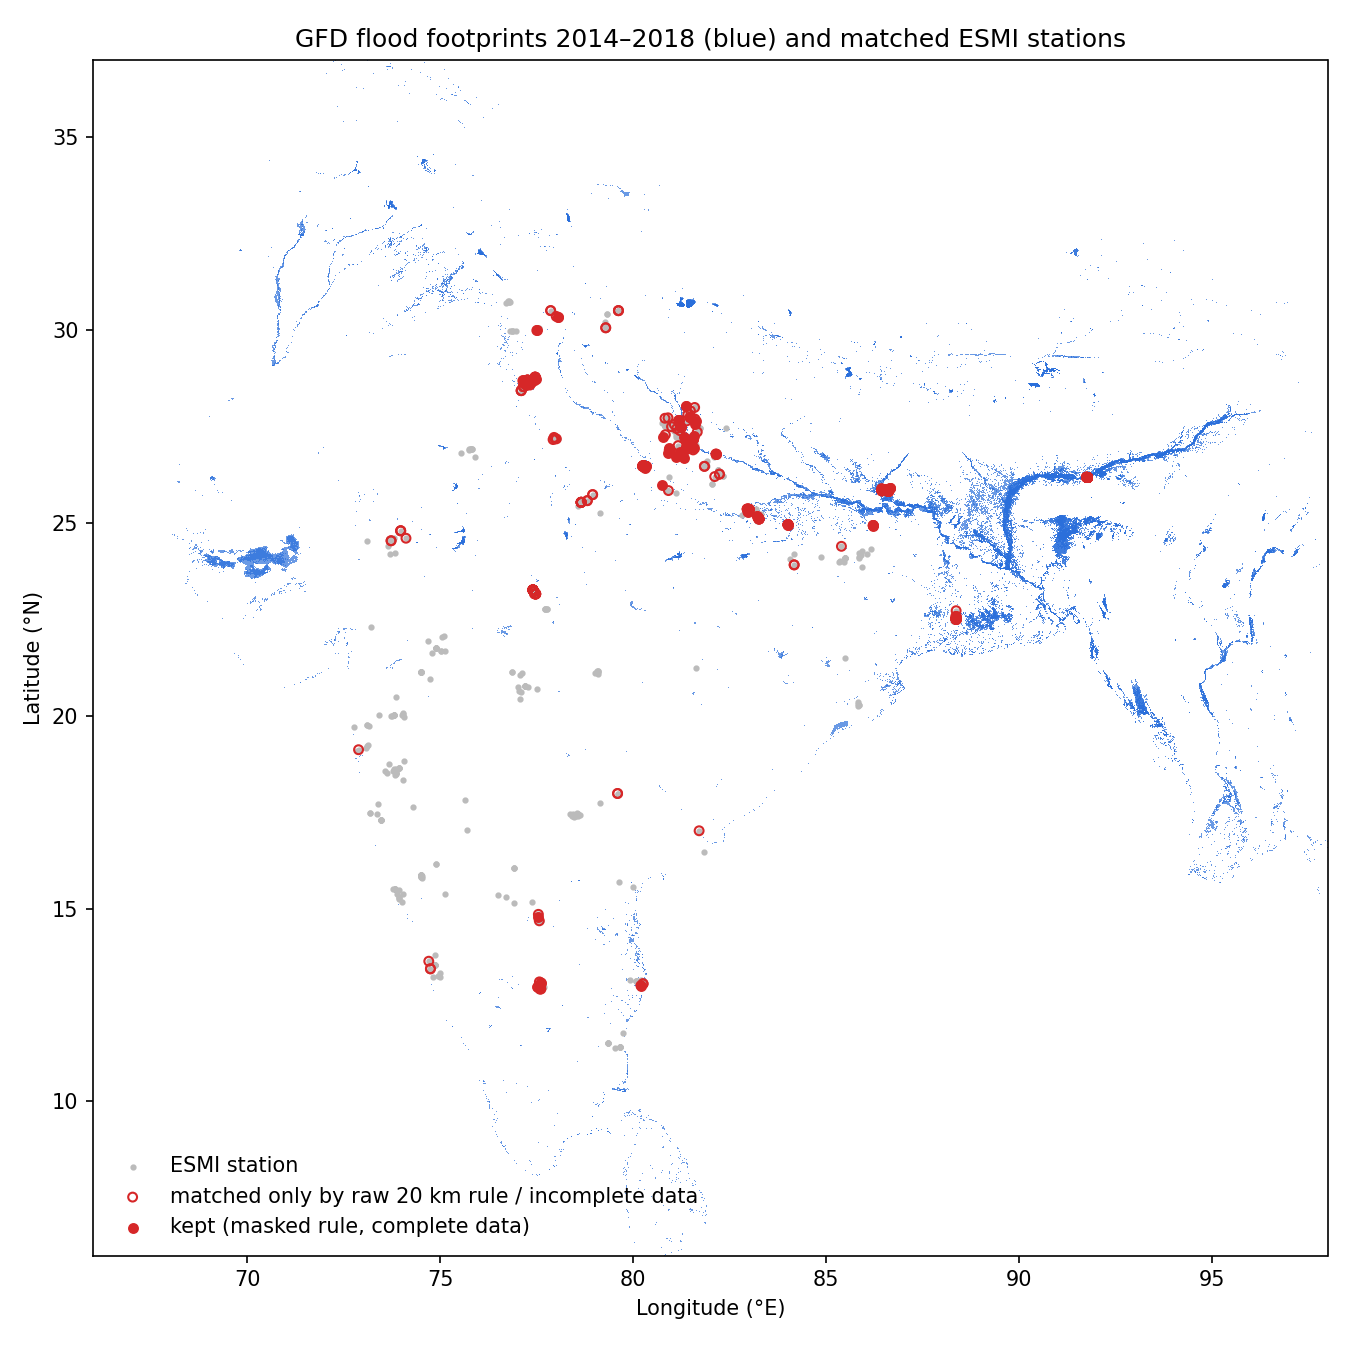

In [4]:
ev = pd.read_csv(ROOT/'data/flood_events.csv')
display(ev[ev.used])
display(Image(str(ROOT/'outputs/figures/04_flood_events_map.png'), width=650))

## 4. Daily panel

In [5]:
print((ROOT/'outputs/06_panel_summary.txt').read_text())

stations: 517
IMD: 1826 days 2014-01-01..2018-12-31; 3x3 valid cells per station: min 5, median 9
AIFS: 1831 init dates needed, 13 missing: [datetime.date(2013, 12, 27), datetime.date(2013, 12, 28), datetime.date(2013, 12, 29), datetime.date(2013, 12, 30), datetime.date(2013, 12, 31), datetime.date(2014, 8, 3), datetime.date(2014, 8, 4), datetime.date(2014, 9, 5), datetime.date(2015, 12, 5), datetime.date(2015, 12, 6), datetime.date(2016, 7, 25), datetime.date(2016, 7, 26), datetime.date(2016, 8, 17)]

panel: 311,778 station-days, 517 stations, 85.3% observed
event-window station-days (kept events): 2,740; event days: 2,062
stations with out_p90 == 0 (disrupt = any outage): 13 of 516
disrupt base rate: all 0.098, event days 0.123

mean rain (mm/day), JJAS observed days:
imd_c        7.76
aifs_l1_c    8.54
aifs_l2_c    8.77
aifs_l3_c    8.72
aifs_l4_c    8.58
aifs_l5_c    8.66

correlation with IMD (centre cell), JJAS:
aifs_l1_c    0.635
aifs_l2_c    0.626
aifs_l3_c    0.613
aifs_l4_c  

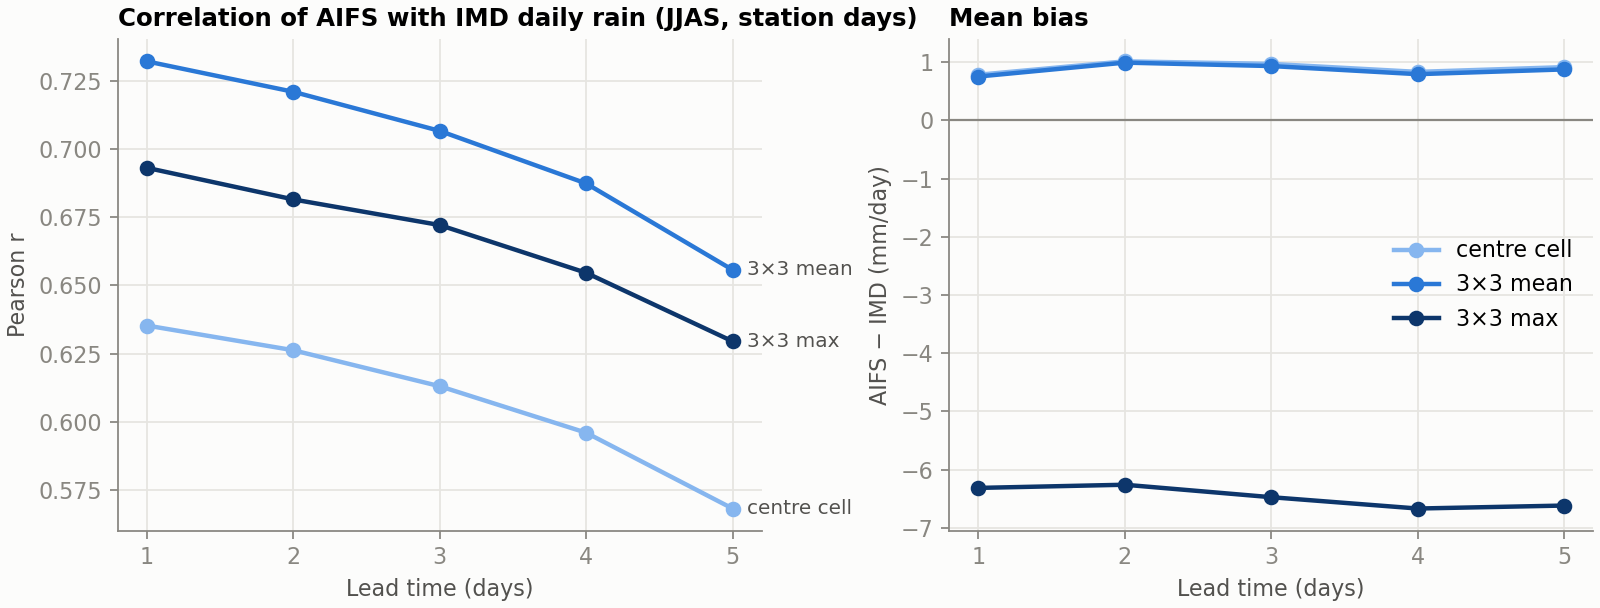

sp,c,m3,x3
lead,,,
1,0.635,0.732,0.693
2,0.626,0.721,0.682
3,0.613,0.707,0.672
4,0.596,0.688,0.655
5,0.568,0.656,0.630


In [6]:
display(Image(str(ROOT/'outputs/figures/08_rain_vs_imd.png'), width=800))
display(pd.read_csv(ROOT/'outputs/08_rain_vs_imd.csv').pivot(index='lead', columns='sp', values='r').round(3))

## 5. Event time series
Station-mean outage minutes (top) and rain (bottom) for each episode.

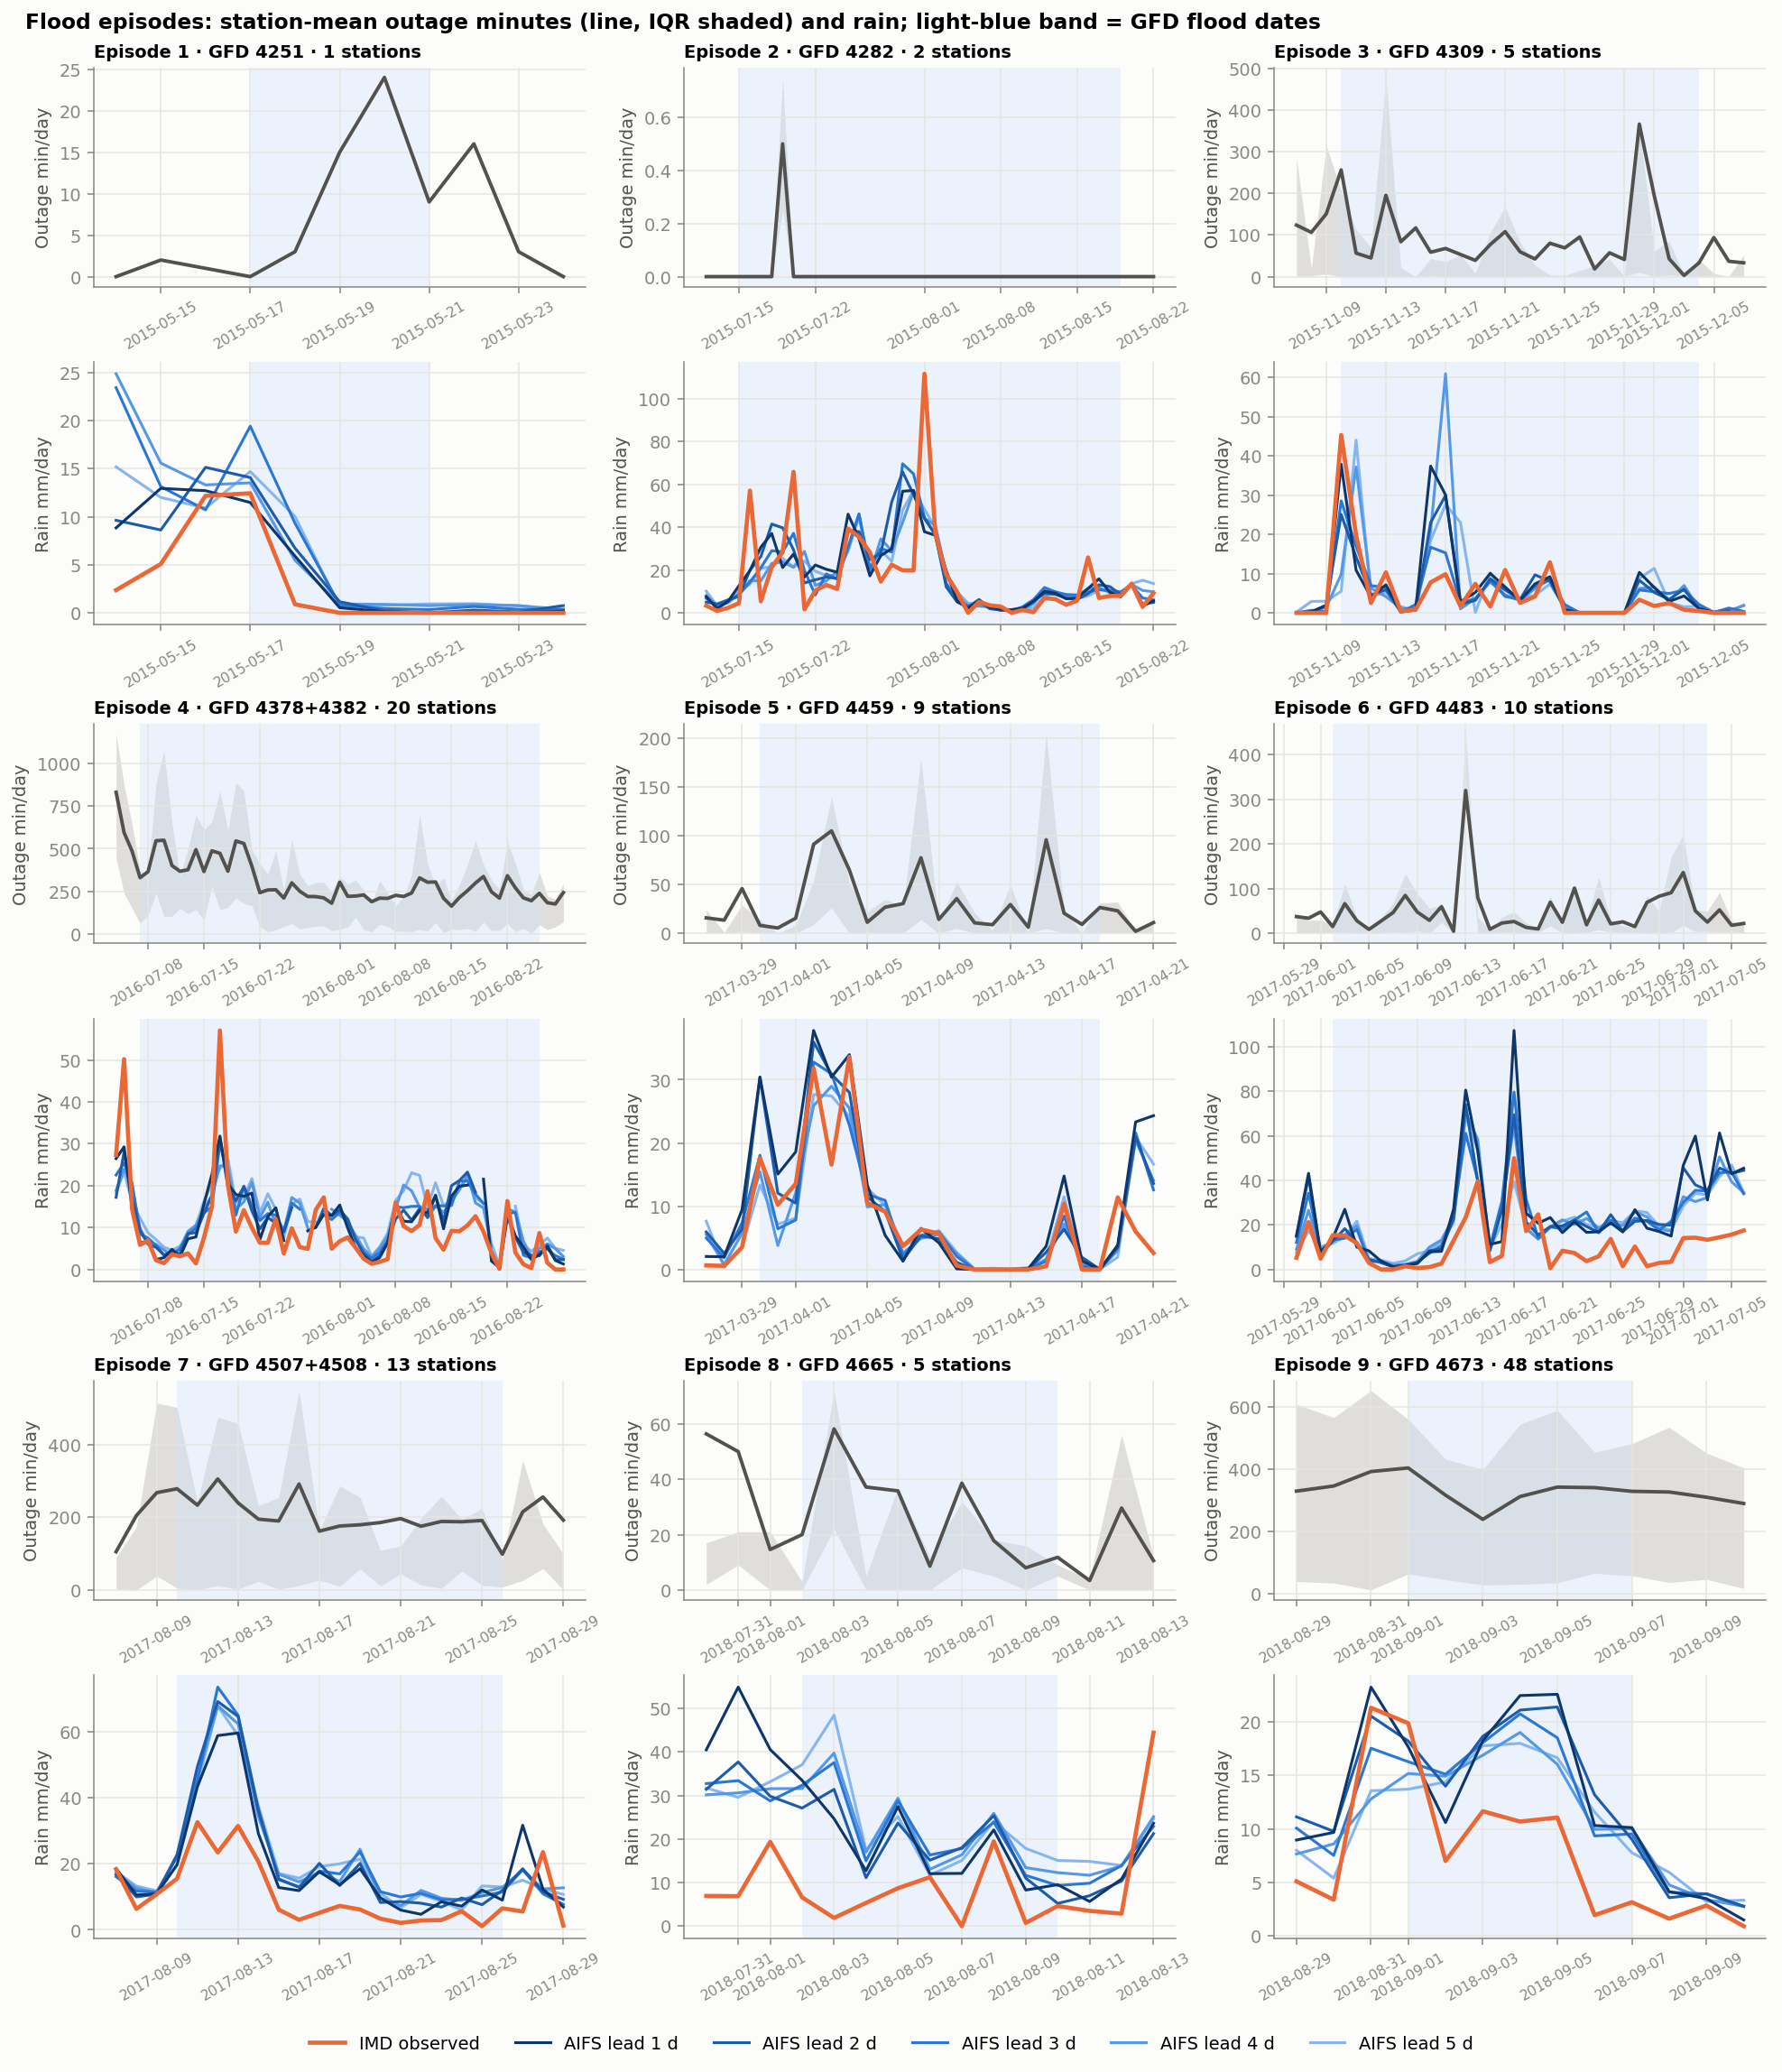

In [7]:
display(Image(str(ROOT/'outputs/figures/08_event_timeseries.png'), width=1000))

## 6. Rain–outage association (in-sample)
Logistic coefficient on log(1 + rain), climatology offset; and a random-intercept-per-station version.

In [8]:
display(pd.read_csv(ROOT/'outputs/07_coefficients.csv').round(4))
display(pd.read_csv(ROOT/'outputs/07_mixed_effects.csv').round(4))

,model,coef_log1p_rain,se,p,odds_ratio_per_e_fold,n
0,imd,0.2386,0.0565,0.0,1.2694,2508
1,aifs_1,0.2991,0.0669,0.0,1.3487,2508
2,aifs_2,0.3080,0.0717,0.0,1.3608,2508
3,aifs_3,0.3153,0.0745,0.0,1.3707,2508
4,aifs_4,0.3133,0.0767,0.0,1.3679,2508
5,aifs_5,0.3427,0.0792,0.0,1.4087,2508


,model,coef_log1p_rain,sd,station_sd,n
0,imd,0.2147,0.0282,0.7151,2508
1,aifs_1,0.3006,0.0228,0.7062,2508
2,aifs_2,0.3071,0.0229,0.7073,2508
3,aifs_3,0.3076,0.0230,0.7069,2508
4,aifs_4,0.2987,0.0230,0.7121,2508
5,aifs_5,0.3306,0.0229,0.7173,2508


## 7. Cross-validated skill
Leave-one-flood-episode-out (event windows) and leave-one-year-out (JJAS).

In [9]:
S = pd.read_csv(ROOT/'outputs/07_skill.csv')
keep = ['clim','imd','imd48','pers_1','aifs_1','aifs_2','aifs_3','aifs_4','aifs_5','aifs_pers_1','aifs_pers_5']
for smp, tr in [('event windows','event-only'), ('event days','event-only'), ('event windows','all days'), ('JJAS all','all days')]:
    d = S[(S.spatial=='m3') & (S.area_type=='all') & (S['sample']==smp) & (S.train==tr) & S.model.isin(keep)]
    display(Markdown(f'**{smp}**, trained on {tr}, n = {int(d.n.iloc[0]):,}'))
    display(d.set_index('model').loc[keep, ['bss','bss_lo','bss_hi','auc','auc_lo','auc_hi']].round(3))

**event windows**, trained on event-only, n = 2,508

,bss,bss_lo,bss_hi,auc,auc_lo,auc_hi
model,,,,,,
clim,0.000,0.000,0.000,0.538,0.491,0.612
imd,0.004,-0.006,0.011,0.562,0.515,0.630
imd48,0.001,-0.008,0.007,0.549,0.500,0.623
pers_1,0.014,0.002,0.024,0.591,0.539,0.656
aifs_1,0.008,0.004,0.013,0.573,0.530,0.648
aifs_2,0.008,0.003,0.014,0.570,0.527,0.647
aifs_3,0.007,0.002,0.014,0.569,0.527,0.643
aifs_4,0.007,0.002,0.012,0.567,0.524,0.639
aifs_5,0.008,0.001,0.014,0.572,0.526,0.647


**event days**, trained on event-only, n = 1,849

,bss,bss_lo,bss_hi,auc,auc_lo,auc_hi
model,,,,,,
clim,0.000,0.000,0.000,0.540,0.481,0.616
imd,0.002,-0.004,0.007,0.553,0.506,0.623
imd48,-0.001,-0.007,0.004,0.542,0.491,0.612
pers_1,0.012,0.000,0.022,0.585,0.542,0.642
aifs_1,0.009,-0.000,0.019,0.572,0.513,0.650
aifs_2,0.009,-0.001,0.021,0.572,0.512,0.651
aifs_3,0.008,0.000,0.018,0.569,0.511,0.652
aifs_4,0.008,-0.001,0.018,0.566,0.507,0.648
aifs_5,0.010,-0.003,0.021,0.571,0.507,0.655


**event windows**, trained on all days, n = 2,508

,bss,bss_lo,bss_hi,auc,auc_lo,auc_hi
model,,,,,,
clim,0.000,0.000,0.000,0.538,0.492,0.615
imd,0.007,-0.005,0.016,0.568,0.519,0.633
imd48,0.004,-0.007,0.013,0.555,0.505,0.626
pers_1,0.018,0.001,0.033,0.604,0.552,0.665
aifs_1,0.006,-0.003,0.014,0.565,0.517,0.644
aifs_2,0.006,-0.003,0.013,0.560,0.512,0.641
aifs_3,0.006,-0.003,0.013,0.559,0.512,0.638
aifs_4,0.006,-0.003,0.012,0.557,0.509,0.636
aifs_5,0.006,-0.003,0.012,0.557,0.509,0.637


**JJAS all**, trained on all days, n = 81,556

,bss,bss_lo,bss_hi,auc,auc_lo,auc_hi
model,,,,,,
clim,0.000,0.000,0.000,0.498,0.480,0.519
imd,0.007,0.005,0.008,0.528,0.510,0.548
imd48,0.004,0.002,0.005,0.518,0.499,0.537
pers_1,0.024,0.021,0.027,0.563,0.547,0.579
aifs_1,0.003,0.002,0.004,0.514,0.494,0.534
aifs_2,0.003,0.002,0.004,0.513,0.494,0.532
aifs_3,0.002,0.001,0.004,0.513,0.494,0.533
aifs_4,0.002,0.001,0.004,0.512,0.493,0.531
aifs_5,0.002,0.001,0.003,0.511,0.492,0.530


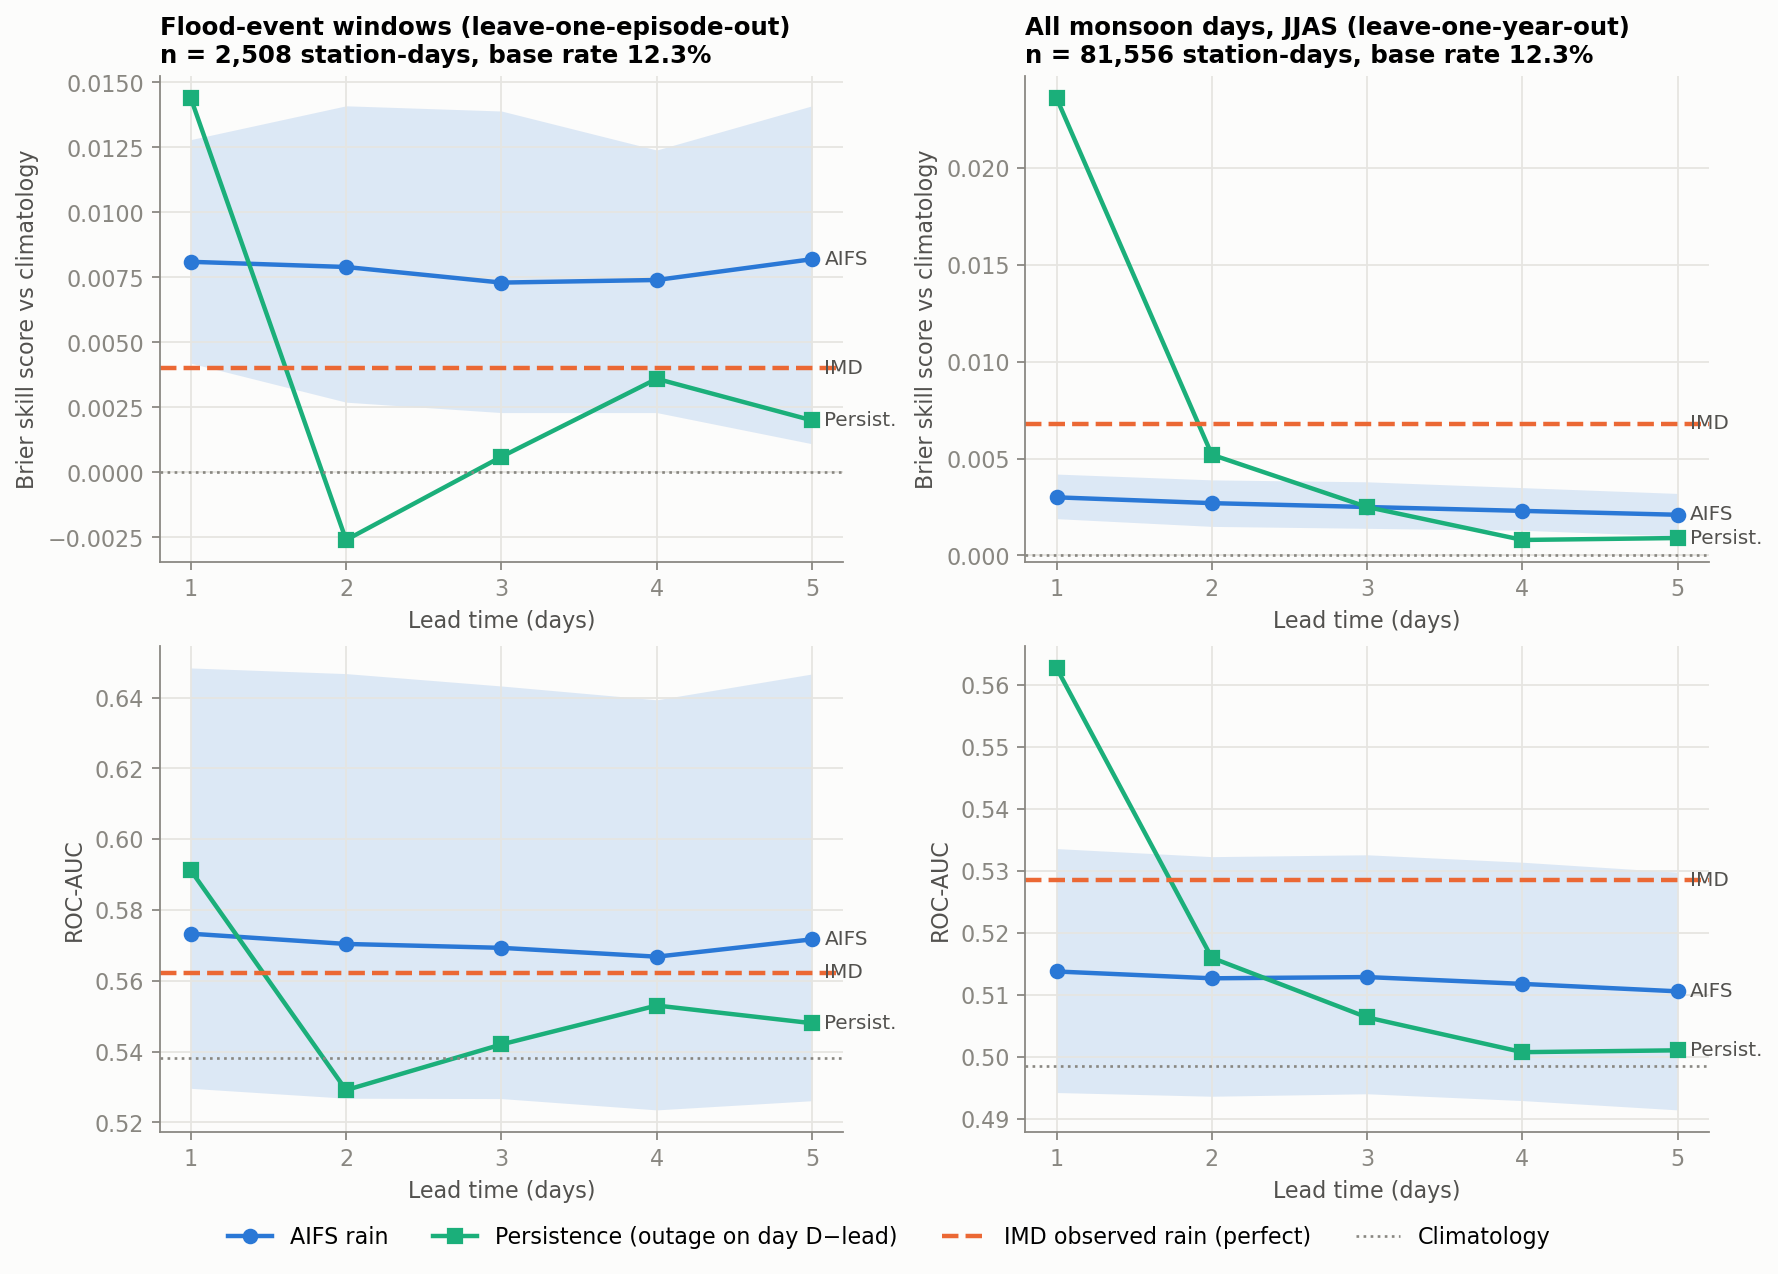

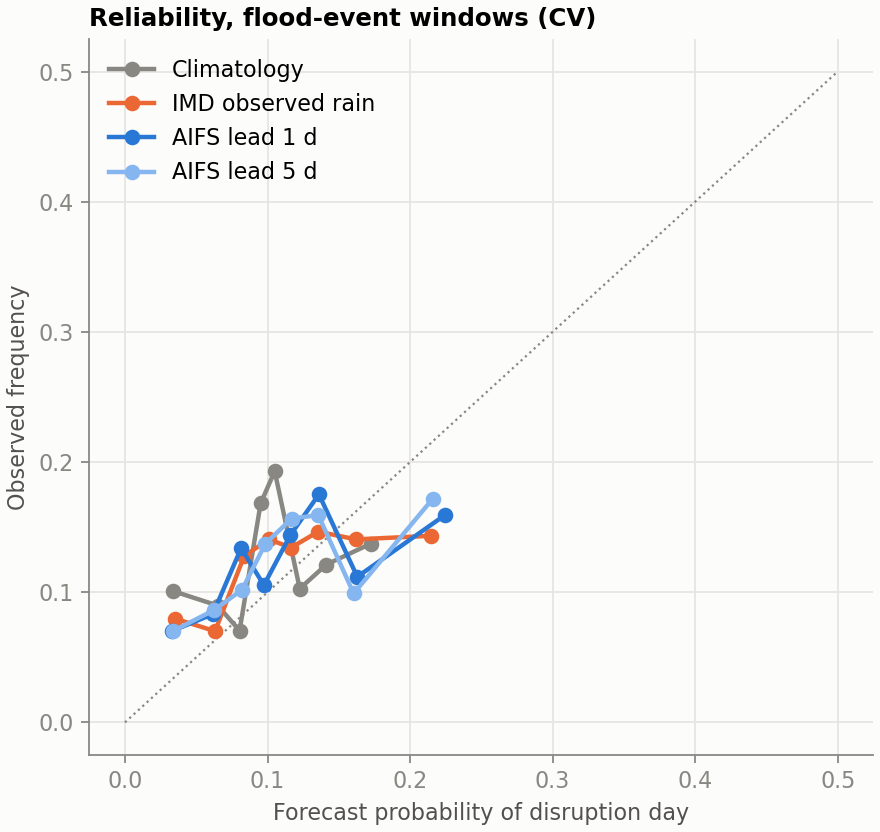

In [10]:
display(Image(str(ROOT/'outputs/figures/08_skill_vs_lead.png'), width=900))
display(Image(str(ROOT/'outputs/figures/08_reliability.png'), width=450))

### Sensitivity to the spatial match (AUC, event windows, event-only training)

In [11]:
d = S[(S.area_type=='all') & (S['sample']=='event windows') & (S.train=='event-only') & S.model.isin(keep)]
display(d.pivot(index='model', columns='spatial', values='auc').loc[keep].round(3))

spatial,c,m3,x3
model,,,
clim,0.538,0.538,0.538
imd,0.566,0.562,0.558
imd48,0.558,0.549,0.548
pers_1,0.591,0.591,0.591
aifs_1,0.576,0.573,0.570
aifs_2,0.571,0.570,0.569
aifs_3,0.569,0.569,0.568
aifs_4,0.567,0.567,0.567
aifs_5,0.573,0.572,0.571


## 8. Urban / peri-urban / rural

model                     aifs_1  aifs_3  aifs_5   clim    imd  pers_1
sample        area_type                                               
JJAS all      peri-urban   0.528   0.527   0.525  0.507  0.544   0.578
              rural        0.517   0.516   0.512  0.488  0.537   0.571
              urban        0.509   0.508   0.506  0.500  0.521   0.555
event windows peri-urban   0.561   0.531   0.528  0.540  0.594   0.530
              rural        0.587   0.579   0.588  0.494  0.590   0.572
              urban        0.572   0.570   0.570  0.550  0.552   0.599

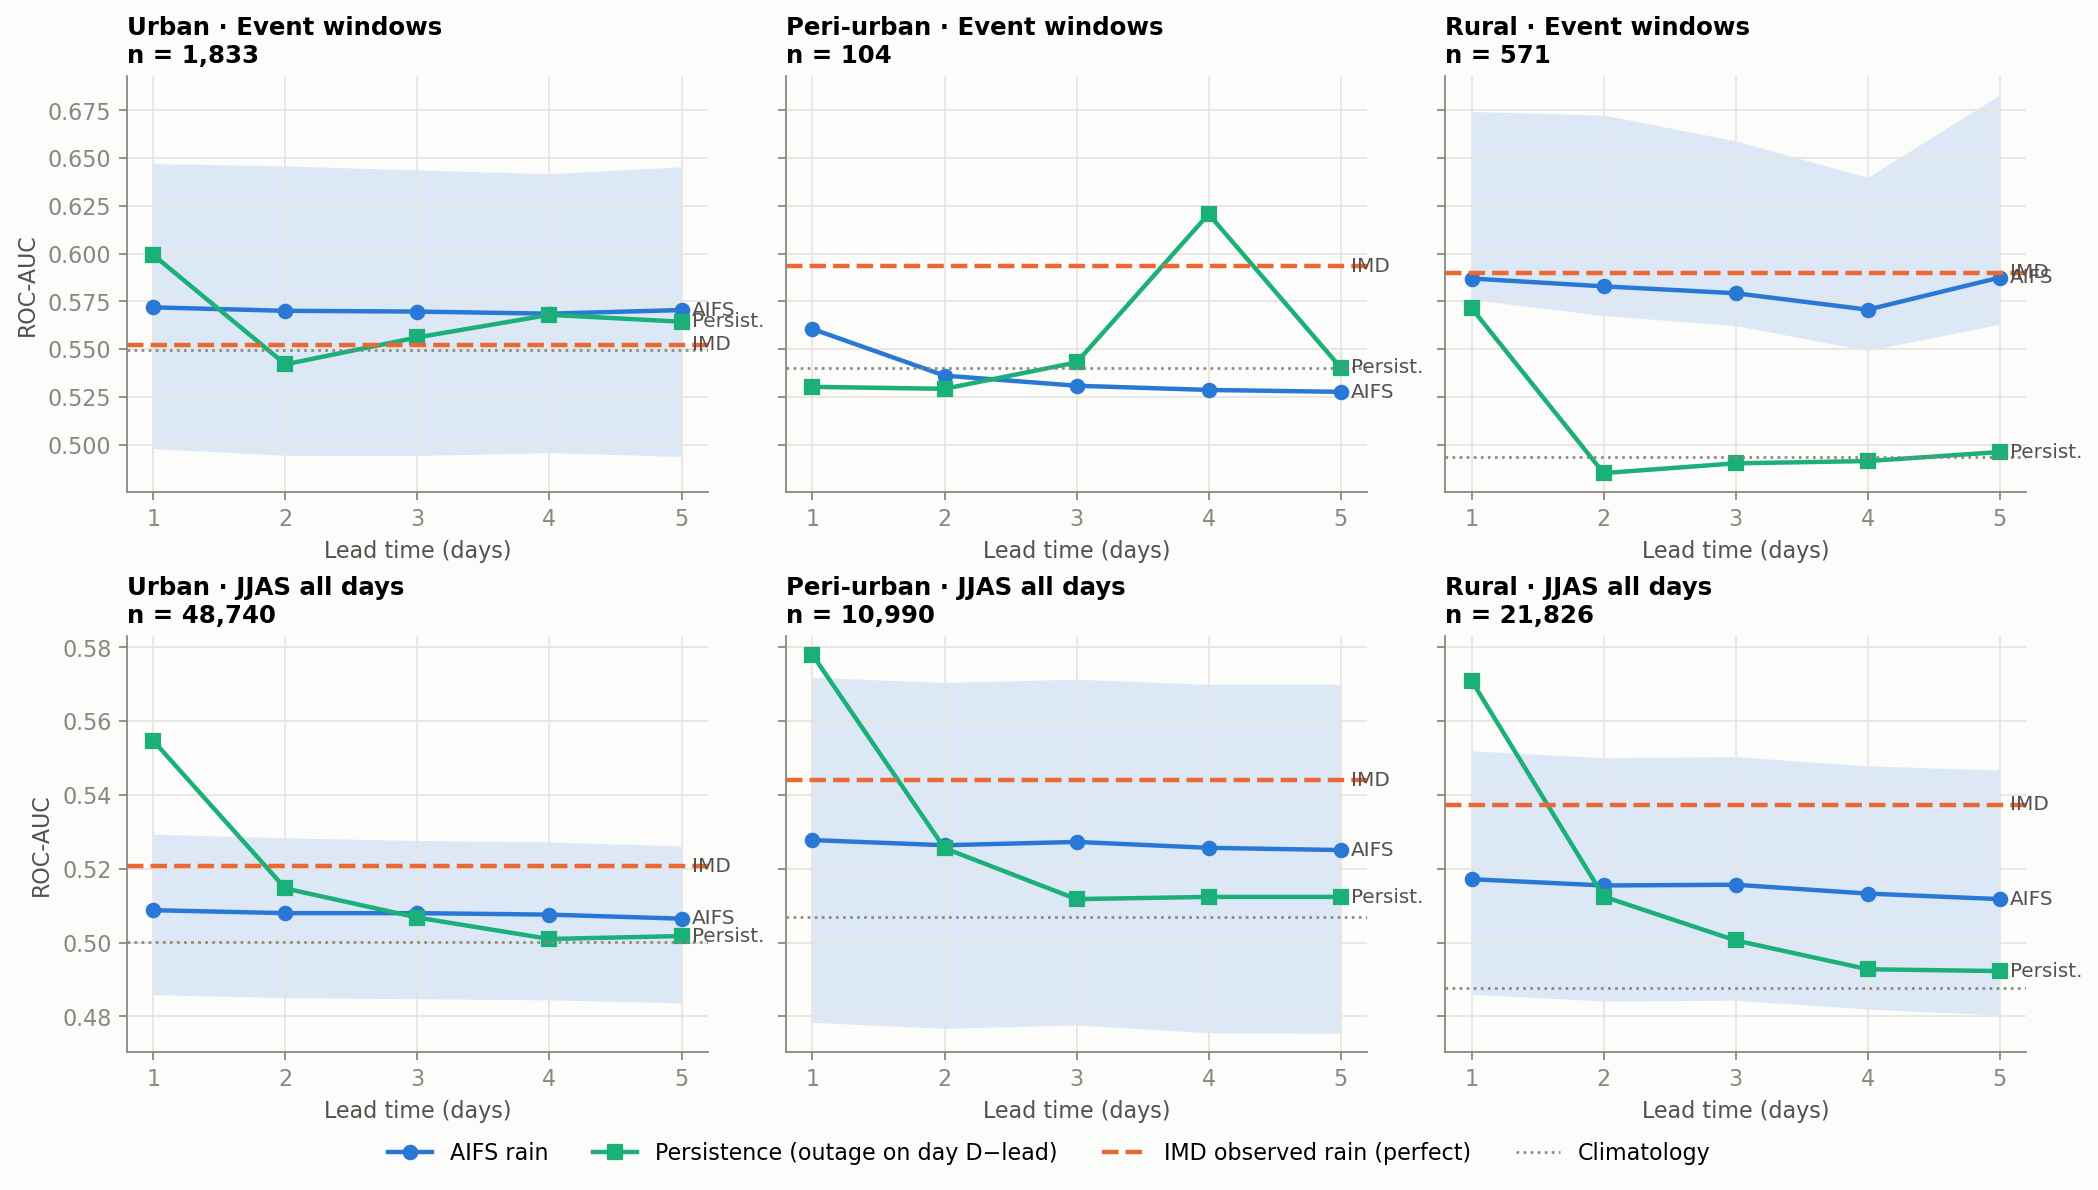

In [12]:
d = S[(S.area_type!='all') & S.model.isin(['clim','imd','pers_1','aifs_1','aifs_3','aifs_5'])]
display(d.pivot_table(index=['sample','area_type'], columns='model', values='auc').round(3))
display(Image(str(ROOT/'outputs/figures/08_skill_by_area.png'), width=1000))

## 9. Skill by episode

In [13]:
E = pd.read_csv(ROOT/'outputs/07_skill_by_episode.csv')
display(E[E.model.isin(['imd','pers_1','aifs_1','aifs_5'])].pivot_table(index=['episode','events','n'], columns='model', values='auc').round(3))

,,model,aifs_1,aifs_5,imd,pers_1
episode,events,n,,,,
2.0,4282,84,0.566,0.651,0.651,0.373
3.0,4309,145,0.574,0.563,0.563,0.581
4.0,4378+4382,664,0.614,0.606,0.610,0.640
5.0,4459,234,0.633,0.611,0.631,0.573
6.0,4483,380,0.550,0.561,0.512,0.560
7.0,4507+4508,299,0.503,0.494,0.495,0.501
8.0,4665,75,0.619,0.573,0.425,0.543
9.0,4673,616,0.516,0.502,0.533,0.577


## 10. Conclusions
See `outputs/SUMMARY.md`: rain raises disruption odds significantly, but cross-validated skill is small (AUC ≈ 0.56–0.57 on flood windows); AIFS matches IMD on event windows and loses little from day 1 to day 5; persistence wins at day 1, AIFS wins at days 2–5; area differences are within noise.